# The Importance of Loss Functions

In this notebook we illustrate how the **choice of loss function** affects the fitted model.

We will study two situations:

1. **Regression without outliers**
2. **Regression with strong outliers**

In both cases we use the **same linear model**, but we change the **loss function** used to estimate the parameters.

We compare four losses:

- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Huber Loss
- Log-Cosh Loss

The goal is to understand how the loss function determines **how errors are penalized** and therefore **which model is learned**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import HuberRegressor
from sklearn.linear_model import QuantileRegressor

from scipy.optimize import minimize

np.random.seed(2)

## Helper functions

We define helper functions to:

- fit the same linear model using different loss functions
- generate predictions
- visualize the fitted models

In [2]:
def fit_models(X_all, y_all):
    """
    Fit linear models using different losses:
    - MSE
    - MAE
    - Huber
    - Log-Cosh
      Log-Cosh is optimized using gradient descent
    # implemented manually because scikit-learn does not provide it directly
    """

    X_all = X_all.reshape(-1,1)

    # MSE
    mse_model = LinearRegression()
    mse_model.fit(X_all, y_all)

    # MAE (Least Absolute Deviations)
    mae_model = QuantileRegressor(
        quantile=0.5,
        alpha=0.0,
        solver="highs"
    )
    mae_model.fit(X_all, y_all)

    # Huber
    huber_model = HuberRegressor()
    huber_model.fit(X_all, y_all)

    # Log-Cosh
    def logcosh_loss(theta):
        w, b = theta
        pred = w * X_all.flatten() + b
        return np.mean(np.log(np.cosh(y_all - pred)))

    res = minimize(logcosh_loss, x0=[0.0,0.0])
    w_logcosh, b_logcosh = res.x

    return {
        "mse": mse_model,
        "mae": mae_model,
        "huber": huber_model,
        "logcosh": (w_logcosh, b_logcosh)
    }


def predict_models(models, x_plot):

    y_mse = models["mse"].predict(x_plot)
    y_mae = models["mae"].predict(x_plot)
    y_huber = models["huber"].predict(x_plot)

    w_logcosh, b_logcosh = models["logcosh"]
    y_logcosh = w_logcosh * x_plot.flatten() + b_logcosh

    return y_mse, y_mae, y_huber, y_logcosh


def plot_results(X_all, y_all, models, title):

    x_plot = np.linspace(X_all.min(), X_all.max(), 300).reshape(-1,1)

    y_mse, y_mae, y_huber, y_logcosh = predict_models(models, x_plot)

    plt.figure(figsize=(8,5))

    plt.scatter(X_all, y_all, label="data")

    plt.plot(x_plot, y_mse, label="MSE", linewidth=3)
    plt.plot(x_plot, y_mae, label="MAE", linewidth=3)
    plt.plot(x_plot, y_huber, label="Huber", linewidth=3)
    plt.plot(x_plot, y_logcosh, label="Log-Cosh", linewidth=3)

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")

    plt.legend()
    plt.grid(True)

    plt.show()

## 1. Linear Regression


### 1.1. Regression without outliers

We first generate a dataset that follows a simple linear trend with small noise.

Since there are **no strong outliers**, we expect all loss functions to produce **similar fitted models**.

#### Generate dataset

In [3]:
# ---------------------------------------------------------
# Clean dataset: no outliers
# ---------------------------------------------------------
n_clean = 30

X_clean = np.linspace(0,10,n_clean)

y_clean = 2*X_clean + 1 + np.random.normal(0,0.8,n_clean)

#### Visualize dataset

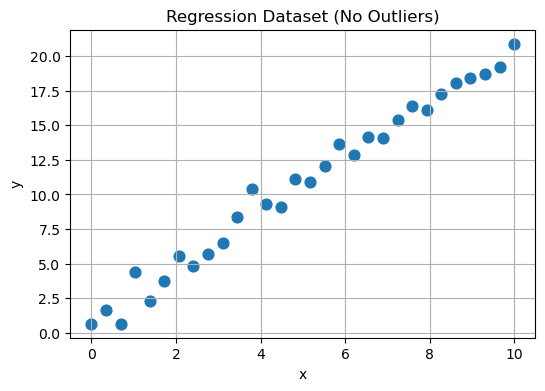

In [4]:
plt.figure(figsize=(6,4))

plt.scatter(X_clean, y_clean, s=60)

plt.title("Regression Dataset (No Outliers)")
plt.xlabel("x")
plt.ylabel("y")

plt.grid(True)

plt.show()

#### Fit models with different losses

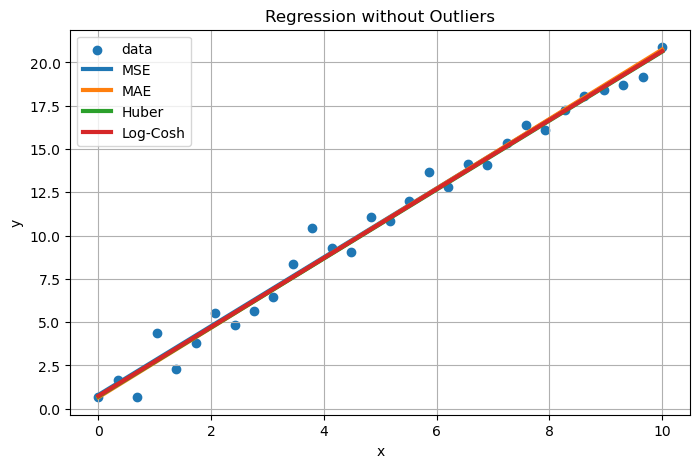

In [5]:
models_clean = fit_models(X_clean, y_clean)

plot_results(X_clean, y_clean, models_clean, "Regression without Outliers")

#### Observation

In the absence of outliers, the fitted lines are almost the same.

This shows that when the data is clean and the model assumptions are approximately satisfied, the choice of loss function has little influence on the fitted model.

### 1.2. Regression with strong outliers

We now keep the same underlying linear trend, but we now add extreme observations that do not follow the linear trend.

This allows us to study how different loss functions react to **large errors**.

We expect:

- **MSE** to be strongly affected by large errors
- **MAE** to be more robust
- **Huber** to behave as a compromise
- **Log-Cosh** to remain smooth while limiting the impact of large errors

#### Generate dataset

In [6]:
# generate inliers

n = 25

X = np.linspace(0,10,n)
y = 2*X + 1 + np.random.normal(0,0.8,n)

# add strong outliers

X_out = np.array([1,2,3,7,8,9])
y_out = np.array([30,28,35,-20,-25,-18])

X_all = np.concatenate([X, X_out])
y_all = np.concatenate([y, y_out])

#### Visualize dataset

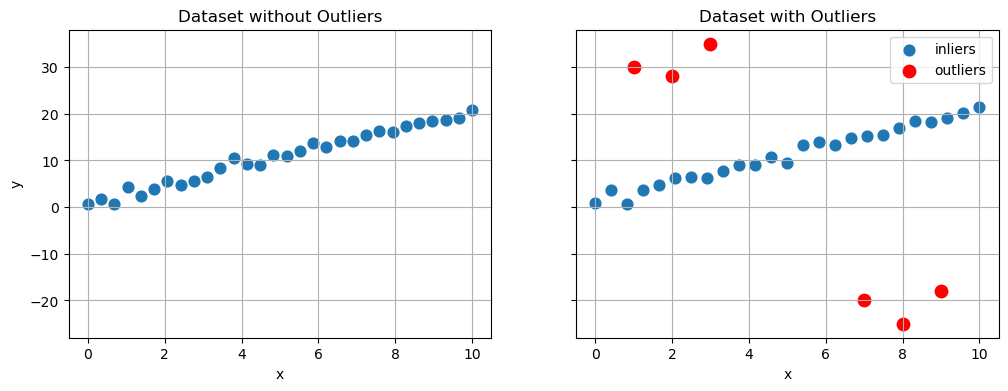

In [7]:
fig, axes = plt.subplots(1,2, figsize=(12,4), sharey=True)

# clean data
axes[0].scatter(X_clean, y_clean, s=60)
axes[0].set_title("Dataset without Outliers")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].grid(True)

# data with outliers
axes[1].scatter(X, y, s=60, label="inliers")
axes[1].scatter(X_out, y_out, color="red", s=80, label="outliers")
axes[1].set_title("Dataset with Outliers")
axes[1].set_xlabel("x")
axes[1].grid(True)
axes[1].legend()

plt.show()

#### Fit models with different losses

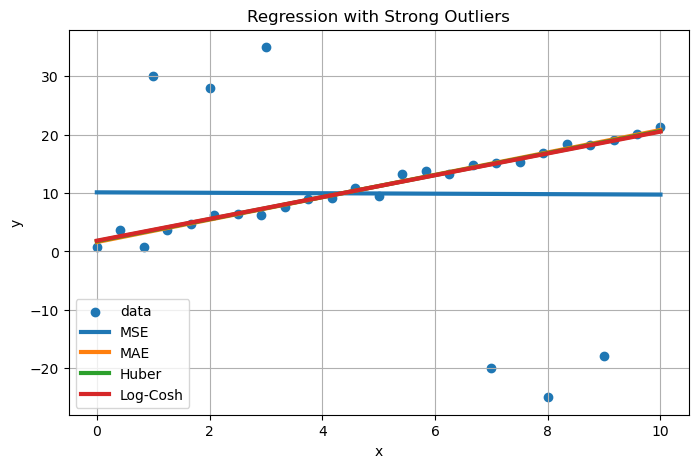

In [8]:
models_outliers = fit_models(X_all, y_all)

plot_results(X_all, y_all, models_outliers, "Regression with Strong Outliers")

#### Observation

Now the differences are clear.

- **MSE** is strongly influenced by outliers because errors are squared.
- **MAE** grows linearly with the residual and is therefore more robust.
- **Huber** behaves like MSE for small residuals (quadratic penalty)
  but like MAE for large residuals (linear penalty).
- **Log-Cosh** is smooth and also reduces the influence of extreme residuals.

This illustrates a key idea in machine learning:

> The loss function defines what type of errors matter most.

#### Loss and Gradient as Functions of the Residual

To better understand why the fitted models behave differently, we now study each loss function as a function of the **residual**

\begin{equation}
e = y - \hat{y}.
\end{equation}

where

- $y$ is the true value,
- $\hat{y}$ is the predicted value.

The loss function assigns a penalty to the magnitude of this residual.
Different loss functions penalize errors in different ways.

We also plot the **derivative with respect to the residual**.

This helps explain:

- why **MSE** reacts strongly to large errors,
- why **MAE** is more robust but non-smooth,
- why **Huber** combines both behaviors,
- and why **Log-Cosh** is smooth while remaining robust.

In [9]:
# ---------------------------------------------------------
# Residual range
# ---------------------------------------------------------
e = np.linspace(-10, 10, 1000)

# ---------------------------------------------------------
# Loss functions
# ---------------------------------------------------------
mse = e**2
mae = np.abs(e)

delta = 2.0
huber = np.where(np.abs(e) <= delta,
                 0.5 * e**2,
                 delta * (np.abs(e) - 0.5 * delta))

logcosh = np.log(np.cosh(e))

# ---------------------------------------------------------
# Derivatives
# ---------------------------------------------------------
mse_grad = 2 * e
mae_grad = np.sign(e)

huber_grad = np.where(np.abs(e) <= delta,
                      e,
                      delta * np.sign(e))

logcosh_grad = np.tanh(e)

#### Visual comparison of losses and gradients

- Gradient Intuition

During training, optimization algorithms update model parameters using the **gradient of the loss**.

\begin{equation}
\theta \leftarrow \theta - \eta \nabla_\theta J(\theta)
\end{equation}

The gradient determines how strongly the model reacts to prediction errors.

Large gradients produce large parameter updates, while small gradients lead to small adjustments.

Different loss functions therefore guide the optimization process in different ways.

The **residual** is the difference between the actual and predicted value.

\begin{equation}
e = y - \hat{y}.
\end{equation}

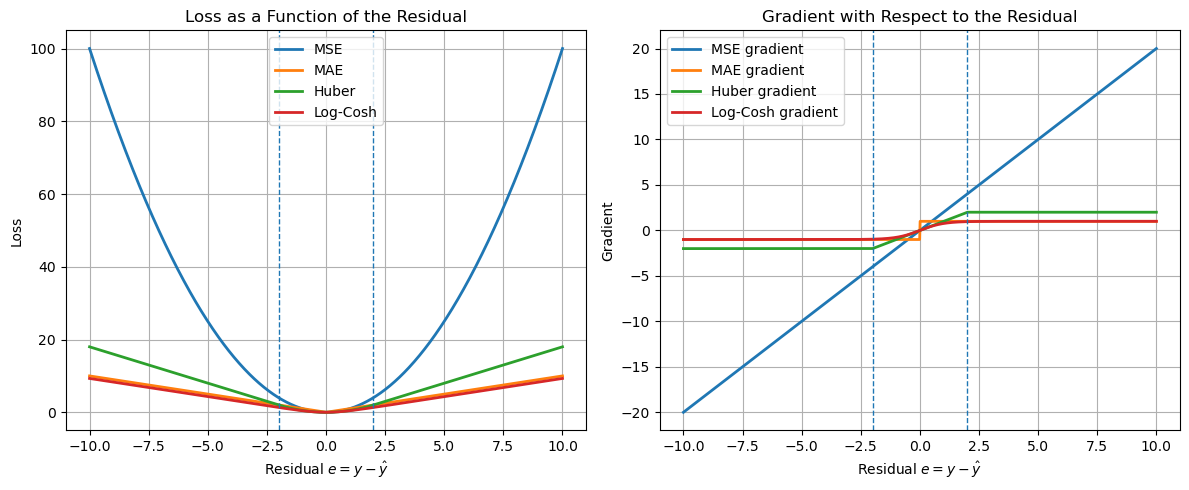

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left: losses ----
axes[0].plot(e, mse, label="MSE", linewidth=2)
axes[0].plot(e, mae, label="MAE", linewidth=2)
axes[0].plot(e, huber, label="Huber", linewidth=2)
axes[0].plot(e, logcosh, label="Log-Cosh", linewidth=2)

axes[0].axvline(delta, linestyle="--", linewidth=1)
axes[0].axvline(-delta, linestyle="--", linewidth=1)

axes[0].set_title("Loss as a Function of the Residual")
axes[0].set_xlabel("Residual $e = y - \\hat{y}$")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ---- Right: gradients ----
axes[1].plot(e, mse_grad, label="MSE gradient", linewidth=2)
axes[1].plot(e, mae_grad, label="MAE gradient", linewidth=2)
axes[1].plot(e, huber_grad, label="Huber gradient", linewidth=2)
axes[1].plot(e, logcosh_grad, label="Log-Cosh gradient", linewidth=2)

axes[1].axvline(delta, linestyle="--", linewidth=1)
axes[1].axvline(-delta, linestyle="--", linewidth=1)

axes[1].set_title("Gradient with Respect to the Residual")
axes[1].set_xlabel("Residual $e = y - \\hat{y}$")
axes[1].set_ylabel("Gradient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Interpretation

These plots explain the behavior observed in the regression experiments.

- **MSE**
  - grows quadratically,
  - has a gradient that becomes very large for large residuals,
  - therefore strongly penalizes outliers.


- **MAE**
  - grows linearly,
  - has constant magnitude gradient away from zero,
  - therefore is more robust to outliers,
  - but it is not differentiable at zero.


- **Huber**
  - is quadratic near zero,
  - becomes linear for large residuals,
  - therefore combines smoothness and robustness.


- **Log-Cosh**
  - behaves like a quadratic loss near zero,
  - grows almost linearly for large residuals,
  - remains smooth everywhere.


Without outliers, all loss functions produce very similar models.

This happens because all residuals are relatively small, and the losses behave similarly near zero.

When strong outliers are present:

- **MSE** heavily penalizes large residuals because the error is squared.
- **MAE** grows linearly and is therefore less sensitive to extreme points.
- **Huber** behaves like MSE for small residuals but switches to a linear penalty for large residuals.

As a result, MAE and Huber produce models that are more **robust to outliers**.

### From Regression Losses to Classification Losses

In regression problems, loss functions are applied to the **residual**

\begin{equation}
e = y - \hat{y}.
\end{equation}

In classification problems, losses are often expressed in terms of the **margin**

\begin{equation}
m = y f(x).
\end{equation}

Both quantities measure how far a prediction is from the desired outcome.
Loss functions penalize these quantities differently, which leads to different learning behaviors.

## 2. Binary Classification

In this notebook we compare two standard approaches to binary classification:

- **Logistic Regression**, trained with **Binary Cross-Entropy**
- **Linear SVM**, trained with **Hinge Loss**

We will use three complementary views:

1. A **clean binary classification dataset** and the corresponding decision boundaries
2. The **loss as a function of the classification margin**
3. The difference between **probabilities** and **decision scores**

The main goal is to understand that even when two models produce similar decision boundaries, the **loss function defines what is being optimized**.

In [11]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

#### Helper functions

We define helper functions to:

- fit Logistic Regression and Linear SVM
- plot the dataset
- plot decision boundaries
- compare probabilities and decision scores

In [12]:
def fit_classification_models(X, y):
    """
    Fit:
    - Logistic Regression (Binary Cross-Entropy)
    - Linear SVM (Hinge Loss)
    """
    log_model = LogisticRegression()
    log_model.fit(X, y)

    svm_model = LinearSVC()
    svm_model.fit(X, y)

    return {
        "logistic": log_model,
        "svm": svm_model
    }


def plot_dataset(X, y, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=60)
    plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.grid(True)
    plt.show()


def plot_decision_boundaries(X, y, models, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z_log = models["logistic"].predict(grid).reshape(xx.shape)
    Z_svm = models["svm"].predict(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    axes[0].contourf(xx, yy, Z_log, alpha=0.2)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, s=60)
    axes[0].set_title("Logistic Regression (BCE)")
    axes[0].set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")
    axes[0].grid(True)

    axes[1].contourf(xx, yy, Z_svm, alpha=0.2)
    axes[1].scatter(X[:, 0], X[:, 1], c=y, s=60)
    axes[1].set_title("Linear SVM (Hinge Loss)")
    axes[1].set_xlabel("$x_1$")
    axes[1].set_ylabel("$x_2$")
    axes[1].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_probability_and_score(X, y, models, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    prob = models["logistic"].predict_proba(grid)[:, 1].reshape(xx.shape)
    score = models["svm"].decision_function(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    c1 = axes[0].contourf(xx, yy, prob, levels=30)
    axes[0].scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", s=50)
    axes[0].set_title("Logistic Regression: Probability")
    axes[0].set_xlabel("$x_1$")
    axes[0].set_ylabel("$x_2$")
    axes[0].grid(True)
    fig.colorbar(c1, ax=axes[0])

    c2 = axes[1].contourf(xx, yy, score, levels=30)
    axes[1].scatter(X[:, 0], X[:, 1], c=y, edgecolor="black", s=50)
    axes[1].set_title("Linear SVM: Decision Score")
    axes[1].set_xlabel("$x_1$")
    axes[1].set_ylabel("$x_2$")
    axes[1].grid(True)
    fig.colorbar(c2, ax=axes[1])

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

### Generate dataset

In [13]:
X_clean, y_clean = make_blobs(
    n_samples=200,
    centers=2,
    cluster_std=1.2,
    random_state=4
)

### Visualize dataset

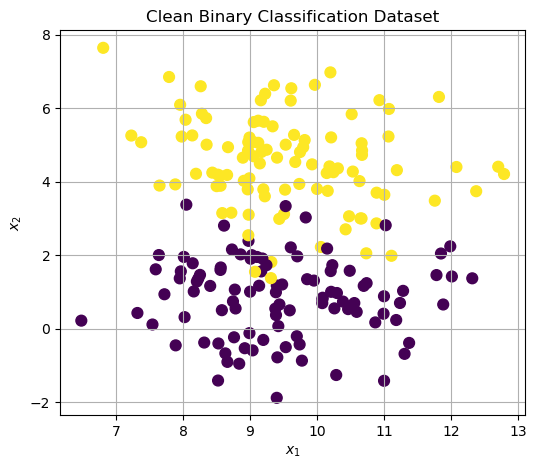

In [14]:
plot_dataset(X_clean, y_clean, "Clean Binary Classification Dataset")

### Fit models with different losses (Logistic Regression and SVM)

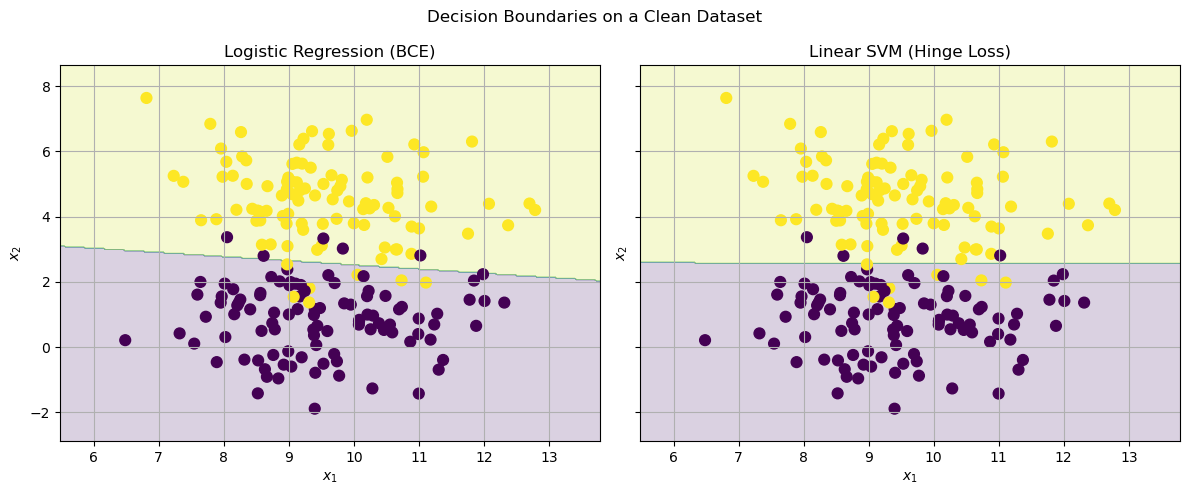

In [15]:
models_clean = fit_classification_models(X_clean, y_clean)

plot_decision_boundaries(
    X_clean,
    y_clean,
    models_clean,
    "Decision Boundaries on a Clean Dataset"
)

### Observation

On a clean and almost linearly separable dataset, both classifiers produce similar decision boundaries.

This is why boundary plots alone are often not sufficient to understand the real difference between the two losses.

### Binary Classification Losses as Functions of the Margin

To understand the real difference between **Binary Cross-Entropy** and **Hinge Loss**, it is useful to analyze them as functions of the **margin**

$$
m = y\,f(x),
$$

where

- $y \in \{-1,+1\}$ is the **true class label**,  
- $f(x)$ is the **classification score** produced by the model.

The margin measures how confident the classifier is in its prediction.

#### Interpretation of the margin

The margin has the following interpretation:

- $m > 0$ : correct classification  
- $m < 0$ : incorrect classification  
- larger positive $m$ indicates a more confident correct classification  

#### Note on label encoding

For margin-based losses (such as **hinge loss** used in Support Vector Machines), it is convenient to use labels

$$
y \in \{-1,+1\}.
$$

In many machine learning libraries (such as `scikit-learn`), labels are instead encoded as

$$
y \in \{0,1\}.
$$

Both encodings represent the same classes, but the $\{-1,+1\}$ convention simplifies the mathematical expression of margin-based losses.

Using the margin allows us to directly compare how different loss functions penalize **errors** and **uncertain predictions**.

In [16]:
# ---------------------------------------------------------
# Margin range
# ---------------------------------------------------------
m = np.linspace(-5, 5, 1000)

# ---------------------------------------------------------
# Losses as functions of the margin
# ---------------------------------------------------------
bce = np.log(1 + np.exp(-m))
hinge = np.maximum(0, 1 - m)

# ---------------------------------------------------------
# Derivatives with respect to the margin
# ---------------------------------------------------------
bce_grad = -1 / (1 + np.exp(m))
hinge_grad = np.where(m < 1, -1, 0)

### Visual comparison of losses and gradients

The following plot shows how different loss functions behave as a function of the margin.

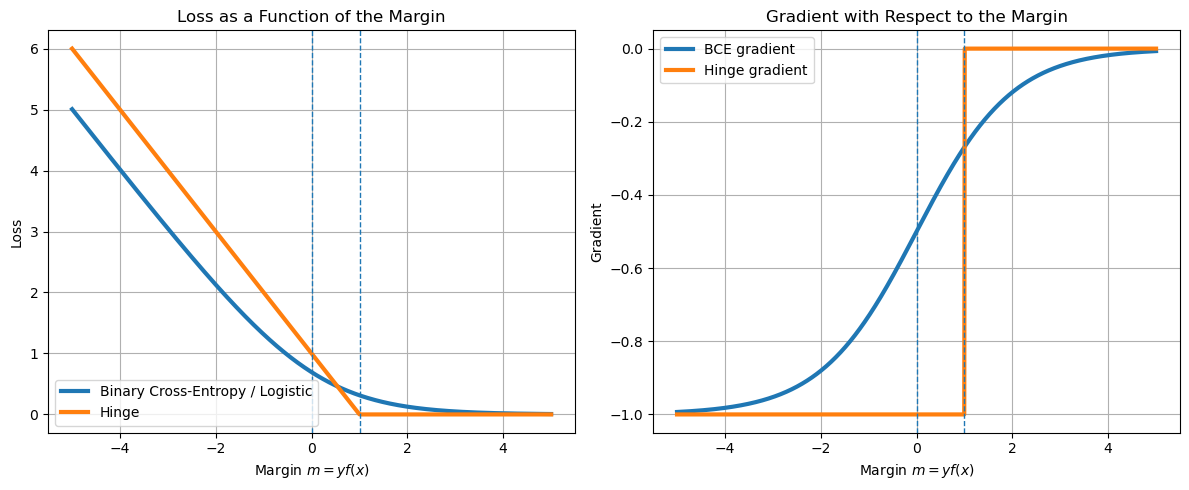

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Left: losses ----
axes[0].plot(m, bce, label="Binary Cross-Entropy / Logistic", linewidth=3)
axes[0].plot(m, hinge, label="Hinge", linewidth=3)

axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].axvline(1, linestyle="--", linewidth=1)

axes[0].set_title("Loss as a Function of the Margin")
axes[0].set_xlabel("Margin $m = y f(x)$")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# ---- Right: gradients ----
axes[1].plot(m, bce_grad, label="BCE gradient", linewidth=3)
axes[1].plot(m, hinge_grad, label="Hinge gradient", linewidth=3)

axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].axvline(1, linestyle="--", linewidth=1)

axes[1].set_title("Gradient with Respect to the Margin")
axes[1].set_xlabel("Margin $m = y f(x)$")
axes[1].set_ylabel("Gradient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Interpretation

This figure shows the essential difference between the two losses.

- **Binary Cross-Entropy**
  - is smooth
  - keeps penalizing even correctly classified points
  - supports a probabilistic interpretation

- **Hinge Loss**
  - is piecewise linear
  - stops penalizing once the margin is at least \(1\)
  - focuses on large-margin classification

So even if the decision boundaries may look similar, the learning objectives are fundamentally different.

### Probability distribution versus decision score

Another important difference is the interpretation of the model output.

- Logistic Regression produces a **probability**.
- Linear SVM produces a **decision score** (a signed distance from the separating hyperplane).

We now visualize this difference on the same dataset.

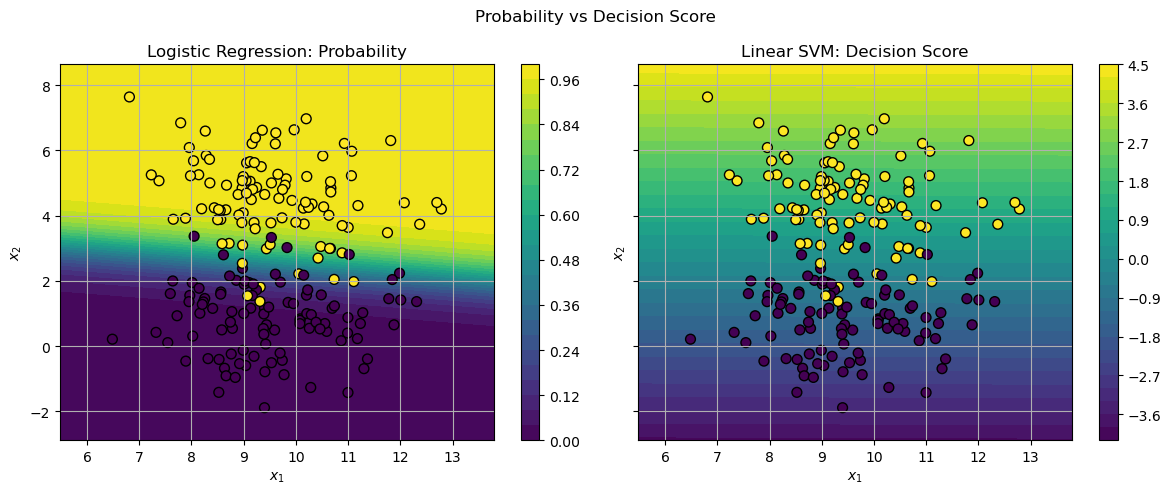

In [18]:
plot_probability_and_score(
    X_clean,
    y_clean,
    models_clean,
    "Probability vs Decision Score"
)

#### Interpretation

The two models encode confidence in different ways.

- **Logistic Regression**
  - returns values between \(0\) and \(1\)
  - these can be interpreted as class probabilities

- **Linear SVM**
  - returns a real-valued score
  - the sign determines the predicted class
  - the magnitude measures distance from the boundary

Thus, the loss function influences not only the training objective, but also the meaning of the output.

## Final conclusion

This section illustrates three important ideas:

1. On simple clean datasets, Logistic Regression and Linear SVM may produce similar decision boundaries.
2. The real conceptual difference becomes clear when we examine the **loss as a function of the margin**.
3. Logistic Regression and SVM also differ in the interpretation of their outputs:
   - probabilities vs scores.

Therefore, in classification, the loss function is not just a technical detail:
it determines both **what is optimized** and **how predictions are interpreted**.